In [1]:
!pip install pyspark google-api-python-client textblob

import nltk
nltk.download("stopwords")
nltk.download("vader_lexicon")

You should consider upgrading via the 'C:\Program Files\Python310\python.exe -m pip install --upgrade pip' command.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\labadmin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\labadmin\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [2]:
from googleapiclient.discovery import build
from googleapiclient.errors import HttpError
import json, os

API_KEY = "YOUR_API_KEY_HERE"
youtube = build("youtube", "v3", developerKey=API_KEY)

def youtube_search(query, max_results=15):
    """Search YouTube for videos for a given query."""
    req = youtube.search().list(
        part="snippet",
        q=query,
        type="video",
        maxResults=max_results
    )
    return req.execute().get("items", [])

def get_video_comments(video_id, max_comments=100):
    """Retrieve up to max_comments comments for a video."""
    comments = []
    try:
        req = youtube.commentThreads().list(
            part="snippet",
            videoId=video_id,
            textFormat="plainText",
            maxResults=max_comments
        )
        res = req.execute()

        for item in res.get("items", []):
            c = item["snippet"]["topLevelComment"]["snippet"]
            comments.append({
                "video_id": video_id,
                "comment_id": item.get("id"),
                "text": c.get("textDisplay"),
                "author": c.get("authorDisplayName"),
                "published_at": c.get("publishedAt"),
            })
        return comments

    except HttpError as e:
        print("Skipped (likely comments disabled):", video_id)
        return []

def save_jsonl(records, filename="comments.jsonl"):
    """Append a list of dicts to a JSONL file."""
    with open(filename, "a", encoding="utf8") as f:
        for r in records:
            json.dump(r, f)
            f.write("\n")

# --------------------------
# SEARCH QUERIES
# --------------------------

GENRE_QUERIES = {
    "Hip Hop": ["hip hop music", "rap music", "90s rap"],
    "Indie":   ["indie music", "indie rock", "indie pop"],
    "Pop":     ["pop music", "billboard pop", "top pop hits"],
}

ARTIST_QUERIES = {
    "Drake": [
        "Drake interview full",
        "Drake 2024 news",
        "Drake controversy",
        "Drake reaction video",
        "Drake new song review",
        "Drake live performance crowd reaction",
        "Drake beef explained",
        "Drake Push Ups",
        "Drake Taylor Made Freestyle",
        "Drake Family Matters",
        "Drake The Heart Part 6"
    ],
    "Kendrick": [
        "Kendrick Lamar interview full",
        "Kendrick Lamar reaction",
        "Kendrick Lamar new song review",
        "Kendrick Lamar live performance reaction",
        "Kendrick Lamar 2024 news",
        "Kendrick vs Drake reaction",
        "Kendrick Lamar Like That",
        "Kendrick Lamar Euphoria",
        "Kendrick Lamar 6:16 in LA",
        "Kendrick Lamar Meet the Grahams",
        "Kendrick Lamar Not Like Us",
    ],
    "DrakeKendrick": [
        "Drake vs Kendrick beef",
        "Kendrick diss track reaction",
        "Drake diss track reaction",
        "Drake vs Kendrick fans reacting",
        "Drake Kendrick feud explained"
    ]
}

# --------------------------
# RUN SCRAPER (ONLY IF FILE MISSING)
# --------------------------

if not os.path.exists("comments.jsonl"):
    print("Collecting data...")

    # Genre-based scraping
    for genre, query_list in GENRE_QUERIES.items():
        for query in query_list:
            print("Searching (GENRE):", query)
            videos = youtube_search(query)
            for v in videos:
                vid = v["id"]["videoId"]
                comments = get_video_comments(vid)
                for c in comments:
                    c["genre_hint"] = genre
                save_jsonl(comments)

    # Artist-based scraping
    for artist, query_list in ARTIST_QUERIES.items():
        for query in query_list:
            print("Searching (ARTIST):", query)
            videos = youtube_search(query)
            for v in videos:
                vid = v["id"]["videoId"]
                comments = get_video_comments(vid)
                for c in comments:
                    c["artist_hint"] = artist
                save_jsonl(comments)

    print("Collection complete.")
else:
    print("comments.jsonl exists — delete it if you want new data.")

An error occurred: module 'importlib.metadata' has no attribute 'packages_distributions'


c:\users\labadmin\appdata\local\programs\python\python38\lib\site-packages\google\api_core\_python_version_support.py:237: FutureWarning: You are using a non-supported Python version (3.8.0). Google will not post any further updates to google.api_core supporting this Python version. Please upgrade to the latest Python version, or at least Python 3.10, and then update google.api_core.
  warnings.warn(message, FutureWarning)


comments.jsonl exists — delete it if you want new data.


In [3]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("YouTubeBatch").getOrCreate()

df = spark.read.json("comments.jsonl")
df.printSchema()
df.show(10, truncate=True)
print("Total raw comments:", df.count())

root
 |-- artist_hint: string (nullable = true)
 |-- author: string (nullable = true)
 |-- comment_id: string (nullable = true)
 |-- genre_hint: string (nullable = true)
 |-- published_at: string (nullable = true)
 |-- text: string (nullable = true)
 |-- video_id: string (nullable = true)

+-----------+------------------+--------------------+----------+--------------------+--------------------+-----------+
|artist_hint|            author|          comment_id|genre_hint|        published_at|                text|   video_id|
+-----------+------------------+--------------------+----------+--------------------+--------------------+-----------+
|       NULL|     @djnoizemusic|UgzafoazIaL2jdqaf...|   Hip Hop|2022-05-11T09:28:30Z|Join my Patreon c...|rwYrEEka1mc|
|       NULL|  @PrisIslandCandy|UgzLe25JC2PfOPlVM...|   Hip Hop|2025-12-07T16:58:40Z|     December 2025🤩|rwYrEEka1mc|
|       NULL|     @Emiola-nb4yd|UgzSXRPKqB6rONfE0...|   Hip Hop|2025-12-07T09:25:02Z|              Hiphop|rwYrEEka1

In [4]:
from pyspark.sql.functions import udf, col
from pyspark.sql.types import BooleanType
from nltk.corpus import stopwords

stopwords_en = set(stopwords.words("english"))

def is_english(text):
    if not text:
        return False
    words = text.lower().split()
    if len(words) == 0:
        return False
    count = sum(1 for w in words if w in stopwords_en)
    return (count / len(words)) >= 0.2

english_udf = udf(is_english, BooleanType())

# Deduplicate using available fields
if "comment_id" in df.columns:
    df_clean = df.dropDuplicates(["comment_id"])
else:
    df_clean = df.dropDuplicates(["video_id", "text"])

df_english = df_clean.filter(english_udf(col("text")) == True)

print("After deduplication:", df_clean.count())
print("English comments:", df_english.count())
df_english.show(10, truncate=True)

After deduplication: 39139
English comments: 28988
+-------------+-------------------+--------------------+----------+--------------------+--------------------+-----------+
|  artist_hint|             author|          comment_id|genre_hint|        published_at|                text|   video_id|
+-------------+-------------------+--------------------+----------+--------------------+--------------------+-----------+
|        Drake|@thecontroversy7914|Ugw--sRYmoR7fQLJI...|      NULL|2025-04-01T04:04:52Z|She could be a tr...|G-Bg0oIlwGE|
|     Kendrick|         @rappadapp|Ugw-3FrIctdmAA7Yu...|      NULL|2024-05-04T14:47:27Z|Im shocked Trackl...|oYKyM5MO9kk|
|     Kendrick|         @irnasyach|Ugw-AG7d0EYxpXGe-...|      NULL|2025-09-08T10:40:33Z|2:37 THE GOOSEBUM...|FPqaXROD1Hc|
|         NULL|  @طوّل_بالك_يا_برو|Ugw-HlT_hyzm04j9A...|   Hip Hop|2025-11-28T22:04:26Z|Comment with date...|me3CPl_i4C4|
|        Drake|         @CapitalMb|Ugw-Kg_ZJ4cJkLUpV...|      NULL|2024-07-27T13:56:12Z|Naaaa I

In [5]:
import re
from pyspark.sql.types import StringType

def clean_text(t):
    if not t:
        return ""
    t = t.lower()
    t = re.sub(r"[^a-zA-Z\s]", "", t)  # keep letters + spaces only
    t = re.sub(r"\s+", " ", t).strip()
    return t

clean_udf = udf(clean_text, StringType())

df_cleaned = df_english.withColumn("clean_text", clean_udf(col("text")))

df_cleaned.select("text", "clean_text").show(10, truncate=False)

+----------------------------------------------------------------------------------------------------------------------------------------------------------+------------------------------------------------------------------------------------------------------------------------------------------------------+
|text                                                                                                                                                      |clean_text                                                                                                                                            |
+----------------------------------------------------------------------------------------------------------------------------------------------------------+------------------------------------------------------------------------------------------------------------------------------------------------------+
|She could be a transformer. He wasn’t taking no risk.                      

In [6]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from textblob import TextBlob
from pyspark.sql.types import FloatType

sia = SentimentIntensityAnalyzer()

def vader_score(text):
    if not text:
        return None
    return float(sia.polarity_scores(text)["compound"])

def vader_label(score):
    if score is None:
        return None
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

def tb_score(text):
    if not text:
        return None
    return float(TextBlob(text).sentiment.polarity)

def tb_label(score):
    if score is None:
        return None
    if score > 0:
        return "positive"
    elif score < 0:
        return "negative"
    else:
        return "neutral"

vader_score_udf = udf(vader_score, FloatType())
tb_score_udf    = udf(tb_score,    FloatType())

from pyspark.sql.types import StringType
vader_label_udf = udf(vader_label, StringType())
tb_label_udf    = udf(tb_label,    StringType())

df_scored = (
    df_cleaned
    .withColumn("vader_score", vader_score_udf(col("clean_text")))
    .withColumn("textblob_score", tb_score_udf(col("clean_text")))
    .withColumn("vader_label", vader_label_udf(col("vader_score")))
    .withColumn("textblob_label", tb_label_udf(col("textblob_score")))
)

df_scored.select("clean_text", "vader_score", "vader_label",
                 "textblob_score", "textblob_label").show(10, truncate=False)

+------------------------------------------------------------------------------------------------------------------------------------------------------+-----------+-----------+--------------+--------------+
|clean_text                                                                                                                                            |vader_score|vader_label|textblob_score|textblob_label|
+------------------------------------------------------------------------------------------------------------------------------------------------------+-----------+-----------+--------------+--------------+
|she could be a transformer he wasnt taking no risk                                                                                                    |0.4023     |positive   |0.0           |neutral       |
|im shocked tracklib took this long to put this out its just the al green track with looped vocals maybe they waited just in case lamar dropped another|-0.3182    |negative

In [7]:
from pyspark.sql.functions import lower, when

df_genre = df_scored.withColumn(
    "genre",
    when(col("genre_hint").isNotNull(), col("genre_hint"))
    .when(
        (lower(col("clean_text")).contains("hip hop")) |
        (lower(col("clean_text")).contains("rap")) |
        (lower(col("clean_text")).contains("trap")),
        "Hip Hop"
    )
    .when(lower(col("clean_text")).contains("indie"), "Indie")
    .when(lower(col("clean_text")).contains("pop"), "Pop")
    .otherwise("Unknown")
)

df_genre.groupBy("genre").count().show()

+-------+-----+
|  genre|count|
+-------+-----+
|Hip Hop| 4732|
|Unknown|21371|
|    Pop| 1465|
|  Indie| 1420|
+-------+-----+



In [8]:
df_final = df_genre.filter(
    col("vader_score").isNotNull() &
    col("textblob_score").isNotNull()
)

print("Rows with valid sentiment scores:", df_final.count())
df_final.select("genre", "clean_text", "vader_score", "textblob_score").show(10, truncate=False)

Rows with valid sentiment scores: 28988
+-------+------------------------------------------------------------------------------------------------------------------------------------------------------+-----------+--------------+
|genre  |clean_text                                                                                                                                            |vader_score|textblob_score|
+-------+------------------------------------------------------------------------------------------------------------------------------------------------------+-----------+--------------+
|Unknown|she could be a transformer he wasnt taking no risk                                                                                                    |0.4023     |0.0           |
|Unknown|im shocked tracklib took this long to put this out its just the al green track with looped vocals maybe they waited just in case lamar dropped another|-0.3182    |-0.31666666   |
|Unknown|your existe

      genre vader_label  count
0   Unknown    positive   7983
1       Pop    negative    165
2       Pop    positive    879
3   Hip Hop    positive   1926
4   Unknown    negative   6329
5     Indie     neutral    354
6   Hip Hop     neutral   1648
7       Pop     neutral    421
8     Indie    positive    874
9   Unknown     neutral   7059
10  Hip Hop    negative   1158
11    Indie    negative    192


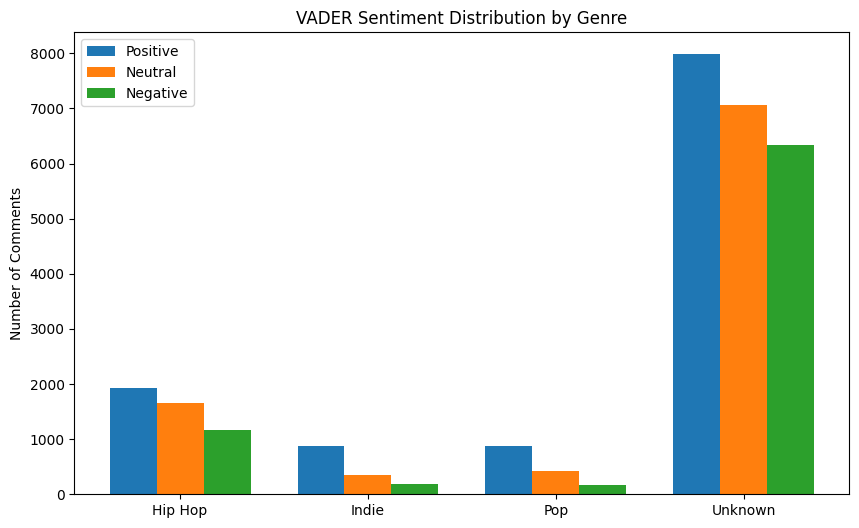

     genre  avg(vader_score)  avg(textblob_score)
0  Hip Hop          0.099513             0.107241
1  Unknown          0.053102             0.071007
2      Pop          0.297180             0.221994
3    Indie          0.326757             0.193746


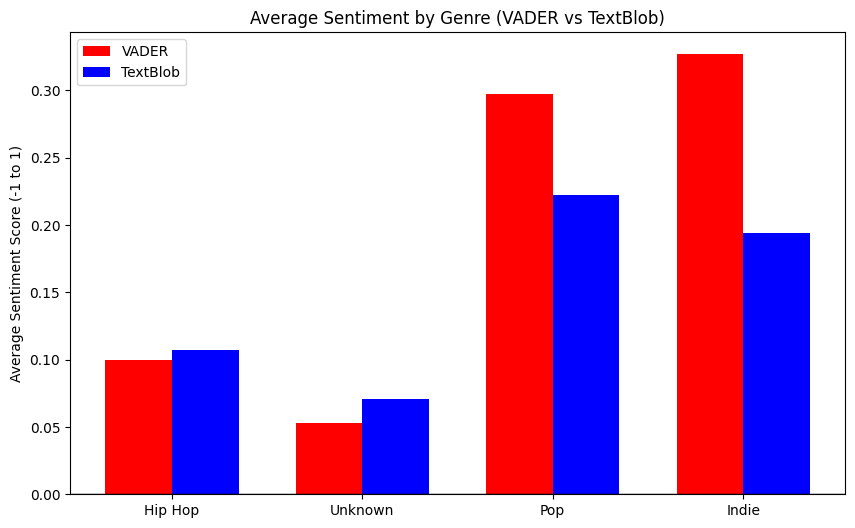

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# ---- VADER sentiment distribution: genre x label ----
genre_sent_dist = (
    df_final.groupBy("genre", "vader_label")
    .count()
    .toPandas()
)

print(genre_sent_dist)

genres = sorted(genre_sent_dist["genre"].unique().tolist())
labels = ["positive", "neutral", "negative"]

# Build matrix: rows=genres, cols=labels
matrix = []
for g in genres:
    row = []
    for lab in labels:
        val = genre_sent_dist[
            (genre_sent_dist["genre"] == g) &
            (genre_sent_dist["vader_label"] == lab)
        ]["count"]
        row.append(int(val.iloc[0]) if not val.empty else 0)
    matrix.append(row)

matrix = np.array(matrix)

# Plot grouped bar chart
x = np.arange(len(genres))
width = 0.25

plt.figure(figsize=(10,6))
for i, lab in enumerate(labels):
    plt.bar(x + i*width - width, matrix[:, i], width, label=lab.capitalize())

plt.xticks(x, genres)
plt.ylabel("Number of Comments")
plt.title("VADER Sentiment Distribution by Genre")
plt.legend()
plt.show()

# ---- Average numeric sentiment by genre ----
genre_avg = (
    df_final.groupBy("genre")
    .avg("vader_score", "textblob_score")
    .toPandas()
)

print(genre_avg)

labels_genre = genre_avg["genre"].tolist()
vader_vals = genre_avg["avg(vader_score)"].tolist()
tb_vals = genre_avg["avg(textblob_score)"].tolist()

x = np.arange(len(labels_genre))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, vader_vals, width, label="VADER", color="red")
plt.bar(x + width/2, tb_vals, width, label="TextBlob", color="blue")
plt.axhline(0, color="black", linewidth=1)

plt.xticks(x, labels_genre)
plt.ylabel("Average Sentiment Score (-1 to 1)")
plt.title("Average Sentiment by Genre (VADER vs TextBlob)")
plt.legend()
plt.show()

In [10]:
from pyspark.sql.functions import when, col, lower

# Build artist column using artist_hint first, then text-based rules
df_artists = df_final.withColumn(
    "artist_raw",
    when(col("artist_hint").isNotNull(), col("artist_hint"))
    .when(lower(col("clean_text")).rlike("drake|champagne papi|ovo"), "Drake")
    .when(lower(col("clean_text")).rlike("kendrick|kdot|kung fu kenny"), "Kendrick Lamar")
    .otherwise("Unknown")
)

# ------------------------------------------
# STANDARDISE ARTIST LABELS (MERGE CATEGORIES)
# ------------------------------------------
df_artists = df_artists.withColumn(
    "artist",
    when(col("artist_raw").isin("Kendrick", "Kendrick Lamar"), "Kendrick Lamar")
    .when(col("artist_raw") == "Drake", "Drake")
    .otherwise("Unknown")
)

# Show final cleaned counts
df_artists.groupBy("artist").count().show(truncate=False)

+--------------+-----+
|artist        |count|
+--------------+-----+
|Unknown       |8594 |
|Drake         |10457|
|Kendrick Lamar|9937 |
+--------------+-----+



In [11]:
# Filter to only Drake & Kendrick rows
drake_df = df_artists.filter(col("artist") == "Drake")
kendrick_df = df_artists.filter(col("artist") == "Kendrick Lamar")

print("Drake comments:", drake_df.count())
print("Kendrick comments:", kendrick_df.count())

Drake comments: 10457
Kendrick comments: 9937


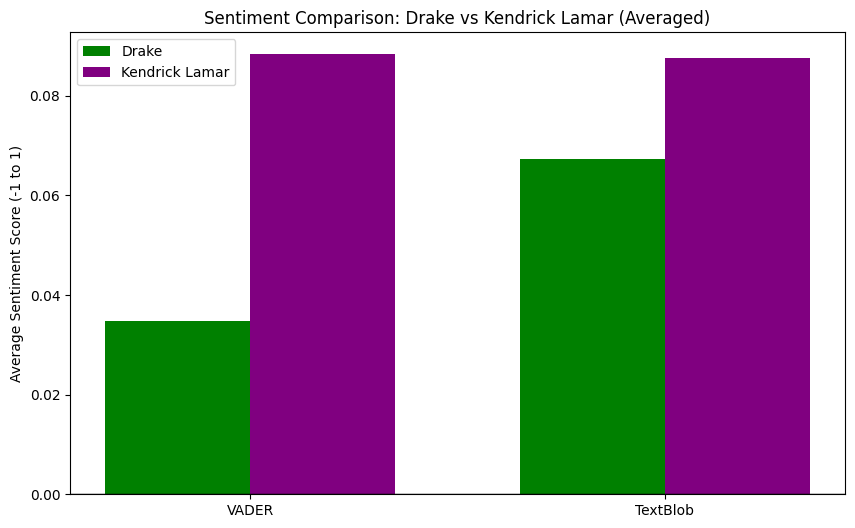

In [12]:
# Compute averages safely (fill NaN with 0 if counts are tiny)
import numpy as np

drake_avg = drake_df.agg(
    {"vader_score": "avg", "textblob_score": "avg"}
).toPandas().iloc[0].fillna(0)

kendrick_avg = kendrick_df.agg(
    {"vader_score": "avg", "textblob_score": "avg"}
).toPandas().iloc[0].fillna(0)

labels = ["VADER", "TextBlob"]
drake_vals = [drake_avg["avg(vader_score)"], drake_avg["avg(textblob_score)"]]
kendrick_vals = [kendrick_avg["avg(vader_score)"], kendrick_avg["avg(textblob_score)"]]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, drake_vals, width, label="Drake", color="green")
plt.bar(x + width/2, kendrick_vals, width, label="Kendrick Lamar", color="purple")
plt.axhline(0, color="black", linewidth=1)

plt.xticks(x, labels)
plt.ylabel("Average Sentiment Score (-1 to 1)")
plt.title("Sentiment Comparison: Drake vs Kendrick Lamar (Averaged)")
plt.legend()
plt.show()

In [13]:
import sys

# Install ipywidgets and wordcloud into the CURRENT kernel env
!{sys.executable} -m pip install ipywidgets wordcloud

import matplotlib.pyplot as plt
from ipywidgets import interact, widgets
import pandas as pd
import numpy as np
from wordcloud import WordCloud

# Convert Spark DataFrame to pandas once for dashboard use
pdf = df_artists.toPandas()

# Quick sanity check
print(pdf.columns)
print("Total rows in pdf:", len(pdf))

Index(['artist_hint', 'author', 'comment_id', 'genre_hint', 'published_at',
       'text', 'video_id', 'clean_text', 'vader_score', 'textblob_score',
       'vader_label', 'textblob_label', 'genre', 'artist_raw', 'artist'],
      dtype='object')
Total rows in pdf: 28988


In [14]:
# Unique genres and models
genre_options = sorted(pdf["genre"].dropna().unique().tolist())
model_options = ["VADER", "TextBlob"]

def plot_genre_sentiment(genre="Hip Hop", model="VADER"):
    # Filter by selected genre
    df = pdf[pdf["genre"] == genre]

    if df.empty:
        print(f"No data for genre: {genre}")
        return

    col_name = "vader_score" if model == "VADER" else "textblob_score"
    scores = df[col_name].dropna()

    if scores.empty:
        print(f"No {model} scores available for {genre}.")
        return

    plt.figure(figsize=(8, 4))
    plt.hist(scores, bins=25, color="skyblue", edgecolor="black")
    plt.title(f"{model} Sentiment Distribution – {genre}")
    plt.xlabel("Sentiment score")
    plt.ylabel("Number of comments")
    plt.grid(alpha=0.3)
    plt.show()

    print(f"{genre} | {model}")
    print(f"  N = {len(scores)}")
    print(f"  Mean = {scores.mean():.3f}")
    print(f"  Std  = {scores.std():.3f}")

interact(
    plot_genre_sentiment,
    genre=widgets.Dropdown(options=genre_options, description="Genre:"),
    model=widgets.ToggleButtons(options=model_options, description="Model:")
)

interactive(children=(Dropdown(description='Genre:', options=('Hip Hop', 'Indie', 'Pop', 'Unknown'), value='Hi…

<function __main__.plot_genre_sentiment(genre='Hip Hop', model='VADER')>

In [15]:
artist_focus = ["Drake", "Kendrick Lamar"]

def compare_artists(model="VADER"):
    col_name = "vader_score" if model == "VADER" else "textblob_score"

    df_d = pdf[pdf["artist"] == "Drake"]
    df_k = pdf[pdf["artist"] == "Kendrick Lamar"]

    if df_d.empty or df_k.empty:
        print("⚠ Not enough artist comments yet for Drake and/or Kendrick.")
        print("Drake rows:", len(df_d), "| Kendrick rows:", len(df_k))
        return

    d_scores = df_d[col_name].dropna()
    k_scores = df_k[col_name].dropna()

    d_mean = d_scores.mean()
    k_mean = k_scores.mean()

    plt.figure(figsize=(6, 4))
    plt.bar(["Drake", "Kendrick"], [d_mean, k_mean], color=["green", "purple"])
    plt.axhline(0, color="black", linewidth=1)
    plt.ylabel("Average sentiment")
    plt.title(f"{model} Sentiment – Drake vs Kendrick Lamar")
    plt.grid(alpha=0.3)
    plt.show()

    print(f"Model: {model}")
    print(f"Drake:    N={len(d_scores)}, mean={d_mean:.3f}")
    print(f"Kendrick: N={len(k_scores)}, mean={k_mean:.3f}")

interact(
    compare_artists,
    model=widgets.ToggleButtons(options=["VADER", "TextBlob"], description="Model:")
)

interactive(children=(ToggleButtons(description='Model:', options=('VADER', 'TextBlob'), value='VADER'), Outpu…

<function __main__.compare_artists(model='VADER')>

In [16]:
# Build selector options
wc_mode_options = ["Genre", "Artist"]

wc_genre_options = sorted(pdf["genre"].dropna().unique().tolist())
wc_artist_options = sorted(pdf["artist"].dropna().unique().tolist())

def make_wordcloud(mode="Genre", value=None, min_freq=3):
    if mode == "Genre":
        if value is None:
            value = wc_genre_options[0]
        df = pdf[pdf["genre"] == value]
        title = f"Word Cloud – Genre: {value}"
    else:
        if value is None:
            value = wc_artist_options[0]
        df = pdf[pdf["artist"] == value]
        title = f"Word Cloud – Artist: {value}"

    if df.empty:
        print("No data for selection:", mode, value)
        return

    # Use clean_text, drop NaNs
    texts = df["clean_text"].dropna().tolist()
    if not texts:
        print("No clean_text available for this selection.")
        return

    big_text = " ".join(texts)

    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        min_word_length=3
    ).generate(big_text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

# Wrapper to connect dropdowns interactively
def wordcloud_dashboard(mode="Genre", value_index=0):
    if mode == "Genre":
        options = wc_genre_options
    else:
        options = wc_artist_options

    if not options:
        print(f"No {mode.lower()} options available.")
        return

    # Clamp index
    value_index = max(0, min(value_index, len(options)-1))
    value = options[value_index]

    make_wordcloud(mode=mode, value=value)

interact(
    wordcloud_dashboard,
    mode=widgets.ToggleButtons(options=wc_mode_options, description="Mode:"),
    value_index=widgets.IntSlider(min=0, max=5, step=1, value=0, description="Index:")
)

interactive(children=(ToggleButtons(description='Mode:', options=('Genre', 'Artist'), value='Genre'), IntSlide…

<function __main__.wordcloud_dashboard(mode='Genre', value_index=0)>

In [17]:
print("=== DATASET SUMMARY ===")
print("Total comments:", len(pdf))
print()

print("By genre:")
print(pdf["genre"].value_counts(dropna=False))
print()

print("By artist:")
print(pdf["artist"].value_counts(dropna=False))
print()

print("VADER mean by genre:")
print(pdf.groupby("genre")["vader_score"].mean())
print()

print("TextBlob mean by genre:")
print(pdf.groupby("genre")["textblob_score"].mean())

=== DATASET SUMMARY ===
Total comments: 28988

By genre:
genre
Unknown    21371
Hip Hop     4732
Pop         1465
Indie       1420
Name: count, dtype: int64

By artist:
artist
Drake             10457
Kendrick Lamar     9937
Unknown            8594
Name: count, dtype: int64

VADER mean by genre:
genre
Hip Hop    0.099513
Indie      0.326757
Pop        0.297180
Unknown    0.053102
Name: vader_score, dtype: float32

TextBlob mean by genre:
genre
Hip Hop    0.107241
Indie      0.193746
Pop        0.221994
Unknown    0.071007
Name: textblob_score, dtype: float32


In [13]:
!del comments.jsonl